In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scarce2 import mc_signal
from scarce2 import characteristics

timestep=0.001
# All dimensions are given in units of um
thickness = 150
pitch = 50
elektrode_size = 40
v_bias = -100
n_eff_0 = 2.7e12
fluence = 2e13


## Single Fluence Charge and Annaeling

In [2]:
n_eff = characteristics.calc_eff_doping(fluence, n_eff_0)


print('Detector Characteristics:')
print('|n_eff| = %s 1/cm^2' %np.format_float_scientific(np.abs(n_eff)[0], 2))
i_leak = characteristics.calc_leakage_current(thickness, pitch, n_eff, v_bias)*1e6
print('i_leak = %.2f uA' %i_leak[0])
c_sensor = characteristics.calc_sensor_capacitance(pitch, v_bias, n_eff)*1e12
print('c_sensor = %.2f pF' %c_sensor[0])
resistivity = characteristics.calc_resistivity(n_eff)
print('c_sensor = %.2f Ohm cm' %resistivity[0])

Detector Characteristics:
|n_eff| = 1.61e+12 1/cm^2
i_leak = -60.17 uA
c_sensor = 91.55 pF
c_sensor = 2769.90 Ohm cm


Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 20%] Meshing curve 2 (Line)
Info    : [ 30%] Meshing curve 3 (Line)
Info    : [ 40%] Meshing curve 4 (Line)
Info    : [ 60%] Meshing curve 5 (Line)
Info    : [ 70%] Meshing curve 6 (Line)
Info    : [ 80%] Meshing curve 7 (Line)
Info    : [ 90%] Meshing curve 8 (Line)
Info    : Done meshing 1D (Wall 0.00878665s, CPU 0.006922s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.624307s, CPU 0.521689s)
Info    : 14567 nodes 29140 elements
Info    : Writing '/tmp/mesh.msh2'...
Info    : Done writing '/tmp/mesh.msh2'


100%|██████████| 10420/10420 [00:11<00:00, 899.58it/s]


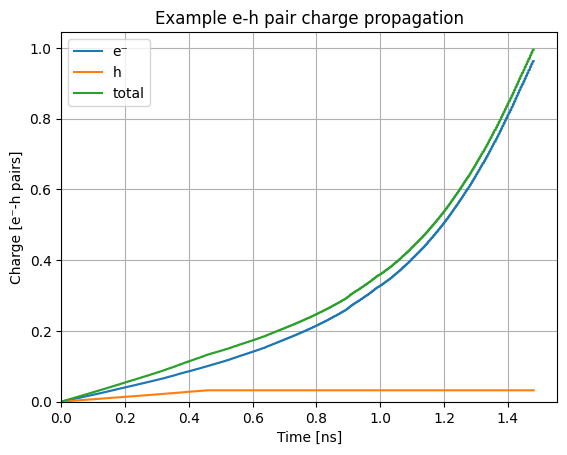

In [3]:
total_charge, charge_e, charge_h = mc_signal.calc_total_charge(timestep, thickness, pitch, elektrode_size, v_bias, n_eff)

abs_charge_e = np.cumsum(charge_e)
abs_charge_h = np.cumsum(charge_h)

abs_time = np.linspace(0, len(charge_e) * timestep, len(charge_e))

fig, ax = plt.subplots()
ax.grid()
ax.plot(abs_time, abs_charge_e, '-', label="e⁻")
ax.plot(abs_time, abs_charge_h, '-', label="h")
ax.plot(abs_time, abs_charge_e + abs_charge_h, '-', label="total")
ax.set_title('Example e-h pair charge propagation')
ax.set_xlabel("Time [ns]")
ax.set_ylabel("Charge [e⁻-h pairs]")
ax.set_xlim(0, None)
ax.set_ylim(0, None)
ax.legend(loc="upper left")
plt.show()

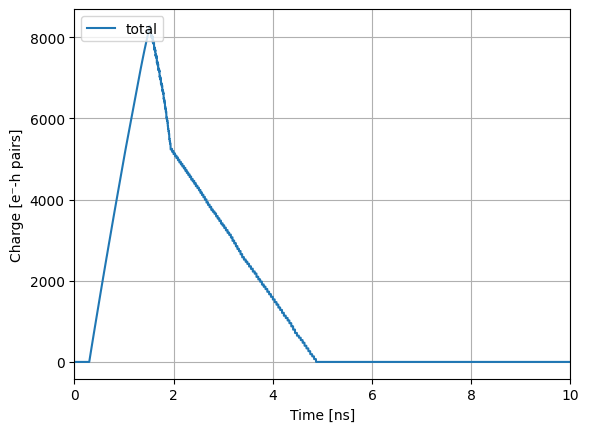

In [4]:
abs_time = np.linspace(0, len(total_charge) * timestep, len(total_charge))
fig, ax = plt.subplots()
ax.grid()
ax.plot(abs_time, total_charge, '-', label="total")
ax.set_xlabel("Time [ns]")
ax.set_ylabel("Charge [e⁻-h pairs]")
ax.set_xlim(0, 10)
# ax.set_ylim(-size, None)
ax.legend(loc="upper left")
plt.show()

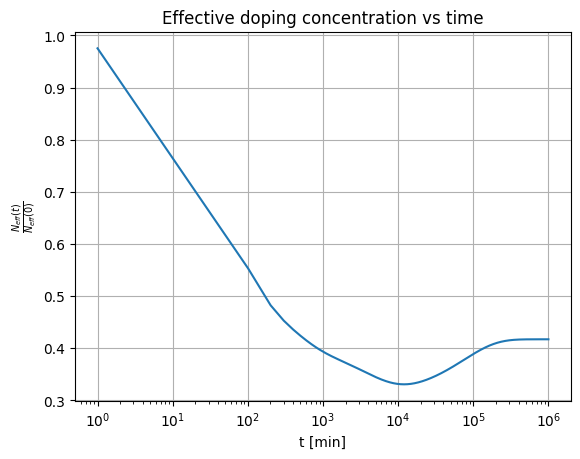

In [5]:
t = np.arange(1e0, 1e6, 1e2)
ratio = characteristics.calc_annealing(t)

fig, ax = plt.subplots()
ax.set_title('Effective doping concentration vs time')
ax.plot(t, ratio)
ax.set_ylabel(r"$\frac{N_{eff}(t)}{N_{eff}(0)}$")
ax.set_xlabel(r"t [min]")
ax.set_xscale('log')
ax.grid()

## Dependency of Detector Characteristics on Fluence

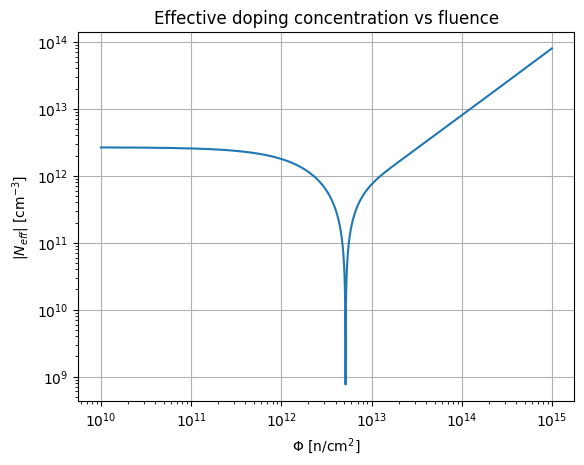

In [6]:
phi = np.arange(1e10, 1e15, 1e10)
n_eff_phi = np.abs(characteristics.calc_eff_doping(phi, n_eff_0))

fig, ax = plt.subplots()
ax.plot(phi[:-1], n_eff_phi)
ax.set_title('Effective doping concentration vs fluence')
ax.set_ylabel(r"|$N_{eff}$| [cm$^{-3}$]")
ax.set_xlabel(r"$\Phi$ [n/cm$^2$]")
ax.grid()
ax.set_xscale('log')
ax.set_yscale('log')

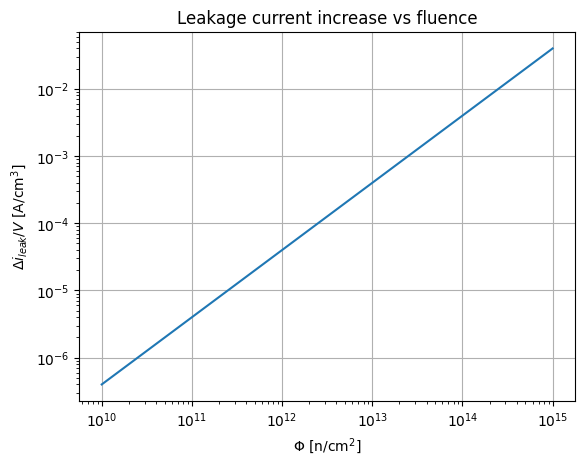

In [7]:
i_leak = characteristics.calc_increase_leakage_current(phi, thickness, pitch)/(pitch*pitch*thickness*1e-4*1e-4*1e-4)

fig, ax = plt.subplots()
ax.set_title('Leakage current increase vs fluence')
ax.plot(phi, i_leak)
ax.set_ylabel(r"$\Delta i_{leak}/ V$ [A/cm$^{3}$]")
ax.set_xlabel(r"$\Phi$ [n/cm$^2$]")
ax.grid()
ax.set_xscale('log')
ax.set_yscale('log')

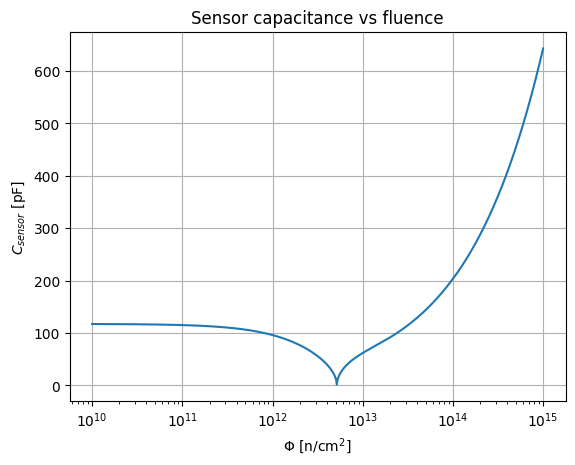

In [8]:

c_cap = characteristics.calc_sensor_capacitance(pitch, v_bias, n_eff_phi)*1e12

fig, ax = plt.subplots()
ax.plot(phi[:-1], c_cap)
ax.set_title('Sensor capacitance vs fluence')
ax.set_ylabel(r"$C_{sensor}$ [pF]")
ax.set_xlabel(r"$\Phi$ [n/cm$^2$]")
ax.set_xscale('log')
ax.grid()